# Part 1 — The surface and its ceiling

A while back I set out to rebuild xwOBA from scratch as a Bayesian model. What came out is what I'm calling **v0**: a BART (Bayesian Additive Regression Trees) categorical model that predicts a batted ball's outcome from three contact measurements — launch speed, launch angle, and sprint speed — and rolls those probabilities up into an expected-wOBA number for each hitter. That's the same information set public Baseball Savant xwOBA is built on, which sets up the two questions this part is about:

1. **Did I actually reproduce it?** Yes — player-season correlation with Savant is **0.956**, calibration error about **0.04**, and the quality saturates early, by roughly 50k training rows.
2. **Can I push past it?** Here it splits in two, and keeping the halves apart is the whole point. At three features v0 sits *exactly* at Savant's information ceiling for **prediction** — next-season parity, r 0.481 vs 0.487. Feeding the surface what Savant lacks — **where the ball was hit**, and which side the batter stands on — genuinely improves how it **describes** a batted ball, by a huge margin, once the model has the tree capacity to use it. It still does not breach the prediction wall.

That second answer took two experiments and a detour into measuring my own ruler. Artifacts: `results/stage_{A,B,C}/`, `results/benchmark/`, `results/stage2_rebuild/`, `results/stage_C_spray/`, `results/capacity_C_m200/` and `results/stage_C_{m200a,m200b,spray_m200}/`, `results/rollup_ab/`.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: /Users/jweinga/Documents/python/xwobart
results:   /Users/jweinga/Documents/python/xwobart/results (exists)


In [2]:
# the artifacts this notebook reads
v0    = jload("stage_C/metrics.json")            # the frozen 3-feature anchor (m_trees = 50)
bm    = jload("benchmark/benchmark_metrics.json")# v0 vs Savant, next-season actual wOBA
rb    = jload("stage2_rebuild/rebuild_report.json")  # R1-R6: the cache rebuild changed nothing
qc    = jload("stage2_rebuild/spray_qc.json")    # S1-S6: spray_pull has the right sign
sp50  = jload("stage_C_spray/metrics.json")      # 5-feature spray at m_trees = 50
cap   = jload("capacity_C_m200/capacity_metrics.json")   # the matched-capacity experiment
sp200 = jload("stage_C_spray_m200/metrics.json") # 5-feature spray at m_trees = 200
v200a = jload("stage_C_m200a/metrics.json")      # v0 at m_trees = 200
ra    = jload("rollup_ab/rollup_ab_metrics.json")# conditioning the season rollup on spray

print("loaded:", ", ".join(["stage_C", "benchmark", "stage2_rebuild", "stage_C_spray",
                            "capacity_C_m200", "stage_C_spray_m200", "stage_C_m200a", "rollup_ab"]))

loaded: stage_C, benchmark, stage2_rebuild, stage_C_spray, capacity_C_m200, stage_C_spray_m200, stage_C_m200a, rollup_ab


## 1. Does v0 reproduce Savant?

I fit the model in three stages. Stage A is a tiny smoke run (5k rows) — just enough to check the wiring, so weak numbers there are expected. The real comparison is B (50k rows) versus C (100k rows): if C looks about the same as B, the model is already data-saturated by ~50k rows and there's little point paying for more.

One caveat on the table: ELPD isn't comparable *across* stages, since each predicts a different number of held-out events.

In [3]:
rows = []
for stage in ("stage_A", "stage_B", "stage_C"):
    m = jload(f"{stage}/metrics.json")
    rep, elpd = m["replication"], m["elpd"]
    rows.append({
        "stage": stage.replace("stage_", ""),
        "fit_rows": m.get("fit_rows"),
        "player_r_holdout": round(rep["player_r_holdout"], 4),
        "event_r_holdout": round(rep["event_r_holdout"], 4),
        "calib_ece": round(m["calibration"]["ece_weighted"], 4),
        "elpd_lppd": round(elpd["elpd_lppd"], 0),
        "elpd_se": round(elpd["elpd_se"], 0),
    })
pl.DataFrame(rows)

stage,fit_rows,player_r_holdout,event_r_holdout,calib_ece,elpd_lppd,elpd_se
"""A""",5000,0.5065,0.8925,0.0581,-13819.0,99.0
"""B""",50000,0.9628,0.9162,0.0376,-80023.0,246.0
"""C""",100000,0.956,0.9105,0.0422,-80107.0,244.0


Player r barely climbs from A to C and ELPD hardly moves: three features get you most of the way there, and they get you there fast. For Stage C, `elpd_lppd` comes in at **−80,107 ± 244** over 122k holdout events — that is the frozen anchor everything later in this notebook is measured against.

So which of the three features does the work? pymc-BART adds features to the surface one at a time, most important first, and tracks the cumulative R² recovered at each step.

In [4]:
vi = v0["variable_importance"]
order = vi["raw"]["indices"]                       # features in importance order
names = [vi["feature_labels"][i] for i in order]
pl.DataFrame({"features used": [names[0]] + [f"+ {n}" for n in names[1:]],
              "cumulative r2": [round(x, 4) for x in vi["raw"]["r2_mean"]]})

features used,cumulative r2
"""launch_angle""",0.8526
"""+ launch_speed""",0.8609
"""+ sprint_speed""",0.8621


Launch angle alone recovers R² 0.853 — it separates grounders from line drives from flies, which *is* most of the outcome. Launch speed gets to 0.861, and sprint speed contributes about +0.001. Keep that last number in mind for the sprint figure below.

Now the pictures. First the headline plot — model xwOBA against public Savant xwOBA, one point per player-season. **What to look for:** how tightly the points hug the diagonal.

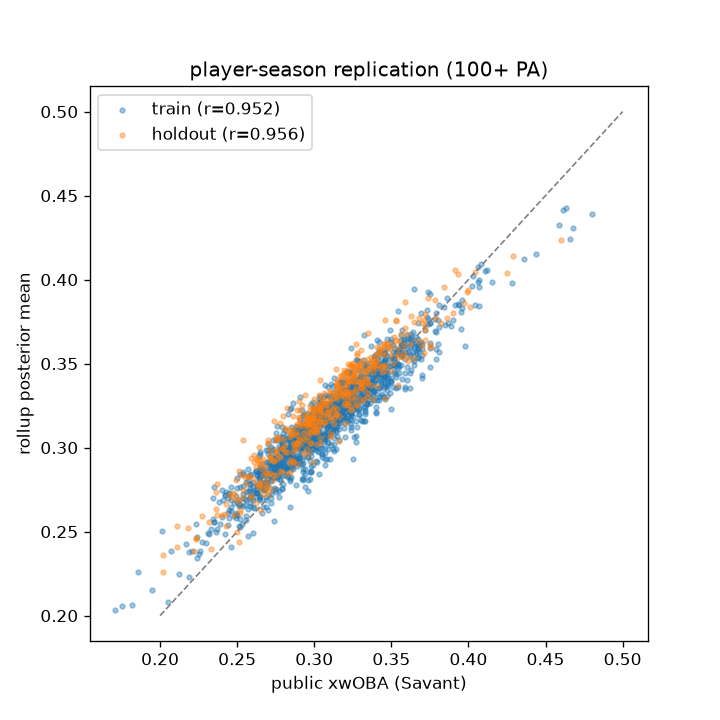

*Player-season xwOBA, model vs Savant — the tight diagonal is the r = 0.956.*

In [5]:
show_fig("stage_C/figures/replication_player.png",
         caption="Player-season xwOBA, model vs Savant — the tight diagonal is the r = 0.956.")

Next, calibration. Within each outcome class the plot bins events by predicted probability and asks how often the outcome actually happened. **What to look for:** points on the dashed 45° line, meaning the probabilities are honest and not merely well-ordered (weighted ECE 0.042). Home runs are the one visible wobble — under-predicted in the top bin.

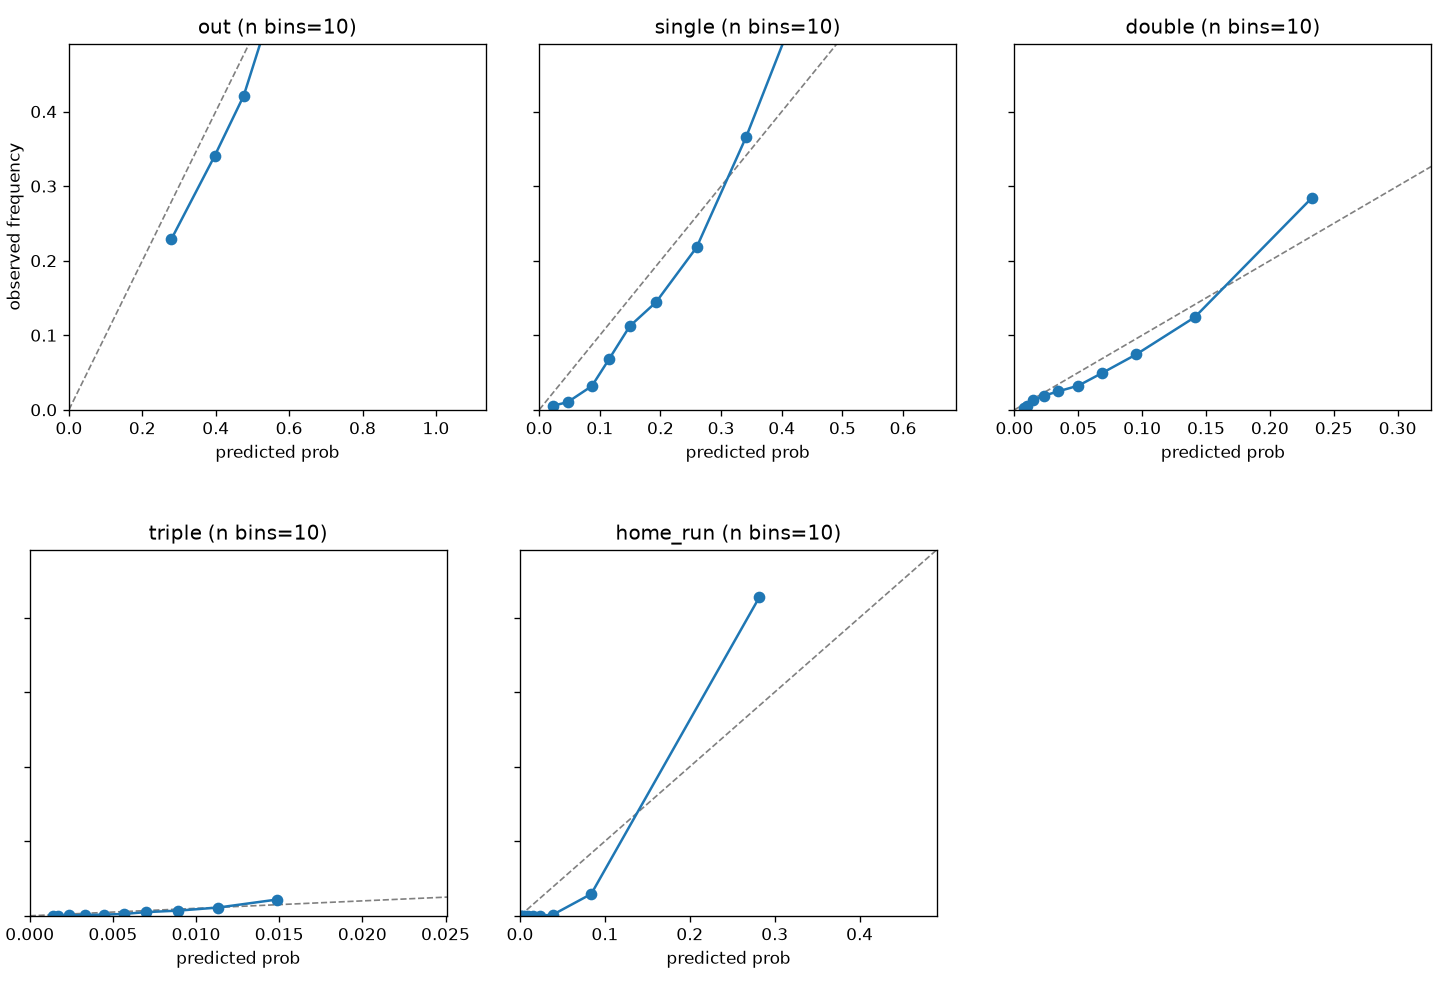

*Reliability by outcome class — points on the dashed diagonal mean honest probabilities.*

In [6]:
show_fig("stage_C/figures/calibration_reliability.png",
         caption="Reliability by outcome class — points on the dashed diagonal mean honest probabilities.")

Last one for this section, and it's a chart to read *backwards* — the flat line is the point.

Freeze two batted balls (a topped grounder at 85 mph / −10°, a barrel at 103 mph / 28°) and vary only the batter's sprint speed. Speed should matter on the grounder — a fast runner beats the throw for an infield single — and do nothing on the barrel, since nobody outruns a ball hit into the seats. A sloppy surface would smear a "fast players are good" bonus over everything. **What to look for:** a gentle rise on the grounder curve and a flat barrel curve — and remember sprint speed is only worth +0.001 R², so the rise *should* be small.

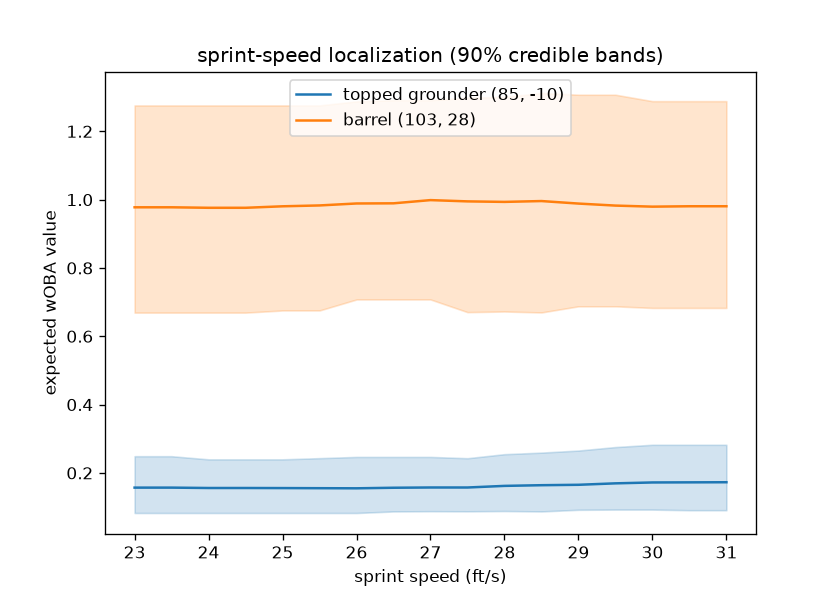

*Expected wOBA of one frozen batted ball vs sprint speed — grounder slope +0.0023 wOBA per ft/s, barrel +0.0009.*

In [7]:
loc = v0["localization"]
show_fig("stage_C/figures/sprint_localization_curves.png",
         caption=f"Expected wOBA of one frozen batted ball vs sprint speed — grounder slope "
                 f"{loc['grounder_slope_per_ftps']:+.4f} wOBA per ft/s, barrel {loc['barrel_slope_per_ftps']:+.4f}.")

Exactly as it should be: weak topped contact gains value as the runner speeds up, barrels don't budge. The held-out events agree — on real topped balls expected value correlates 0.03 with sprint speed, on real barrels 0.002.

**v0 is a faithful, well-calibrated reconstruction of xwOBA from three contact features.** Which raises the obvious next question.

## 2. Is it *more accurate* than Savant? No — and that's the wall

Reproducing a metric isn't the same as improving on it. The honest test of any xwOBA number is whether *this* year's value predicts *next* year's **actual** wOBA. I line up three predictors — v0, public Savant xwOBA, and a naive "just use last year's actual wOBA" baseline — on the 1,058 player-pairs with 100+ PA in both years.

In [8]:
p = bm["pooled"]
pl.DataFrame([
    {"predictor": "v0 model", "r": round(p["model"]["r"], 4), "rmse_calibrated": round(p["model"]["rmse_calibrated"], 4)},
    {"predictor": "Savant",   "r": round(p["savant"]["r"], 4), "rmse_calibrated": round(p["savant"]["rmse_calibrated"], 4)},
    {"predictor": "naive (last-yr wOBA)", "r": round(p["naive"]["r"], 4), "rmse_calibrated": round(p["naive"]["rmse_calibrated"], 4)},
])

predictor,r,rmse_calibrated
"""v0 model""",0.4807,0.0346
"""Savant""",0.4871,0.0345
"""naive (last-yr wOBA)""",0.3904,0.0363


v0 and Savant look close, but "close" needs a number. Bootstrapping the difference in their correlations settles it.

In [9]:
b = bm["model_vs_savant_bootstrap"]
display(pl.DataFrame([{
    "n pairs": bm["n_pairs"],
    "r(model) − r(savant)": f"{b['r_model_minus_r_savant']:+.4f}",
    "95% CI": f"[{b['ci95'][0]:+.4f}, {b['ci95'][1]:+.4f}]",
    "model better in": f"{b['frac_model_better']:.0%} of bootstraps",
}]))
parity = b["ci95"][0] < 0 < b["ci95"][1]
Markdown(f"**The 95% CI {'straddles' if parity else 'excludes'} 0 → "
         f"{'statistical parity: v0 does not beat Savant' if parity else 'a real gap'}. "
         f"Both clearly beat the naive baseline, so v0 is genuine xwOBA.**")

n pairs,r(model) − r(savant),95% CI,model better in
1058,"""-0.0063""","""[-0.0246, +0.0128]""","""26% of bootstraps"""


**The 95% CI straddles 0 → statistical parity: v0 does not beat Savant. Both clearly beat the naive baseline, so v0 is genuine xwOBA.**

Same story in one plot. **What to look for:** on the left, v0 and Savant a hair apart with the naive baseline well behind; on the right, Savant winning 2022→23 and v0 the other two. Nobody wins consistently — that's what parity looks like.

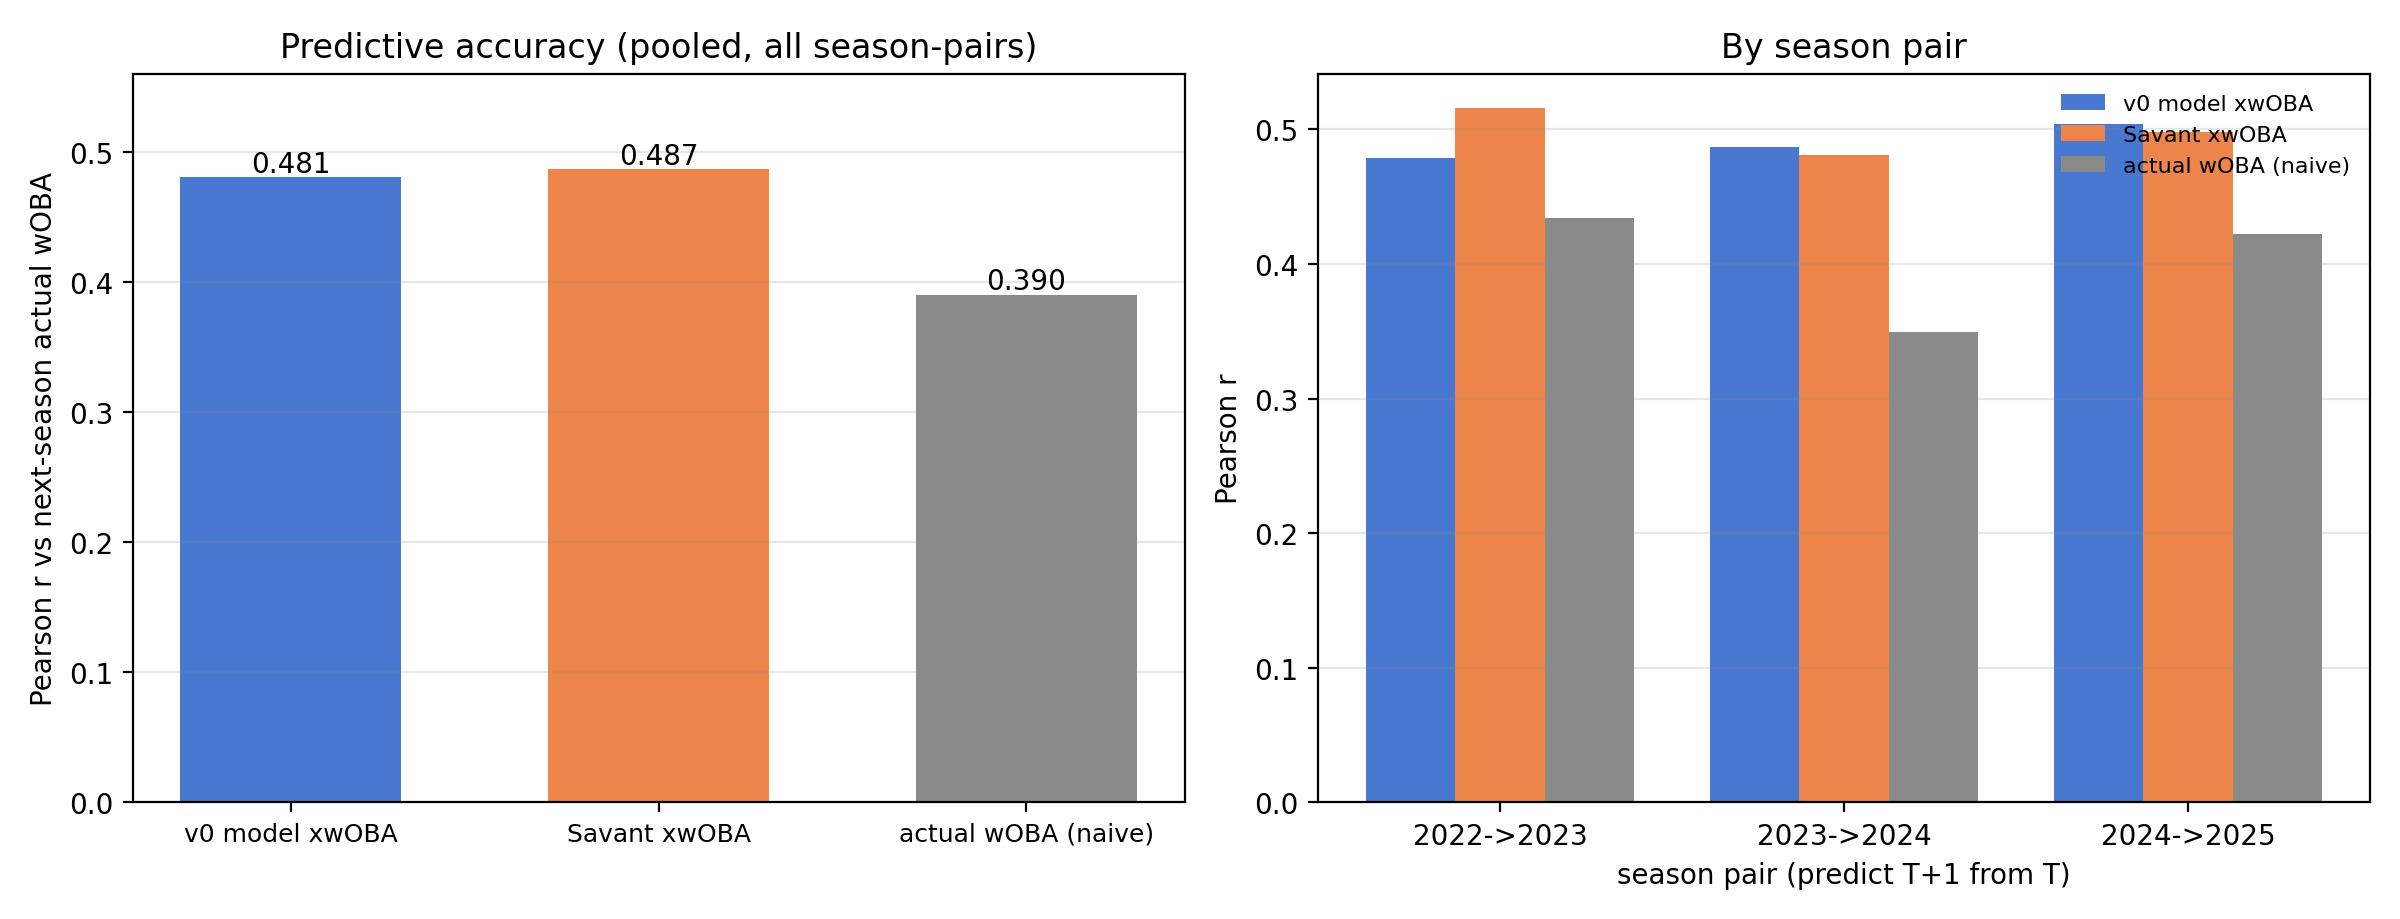

*Correlation with next season's actual wOBA — pooled (left) and by season pair (right).*

In [10]:
show_fig("benchmark/figures/predictive_accuracy.png",
         caption="Correlation with next season's actual wOBA — pooled (left) and by season pair (right).")

The reading: the 3-feature model sits right at Savant's **information ceiling**. Fiddling with the model won't beat Savant — the only way past this wall is to feed it inputs Savant doesn't have. The obvious candidate is **where the ball was hit**: Savant's xwOBA is computed from exit velocity and launch angle alone and is completely blind to spray direction, even though a 100-mph fly ball down the line and the same ball to straightaway centre are not worth the same.

That gives a concrete target: pooled r above **0.487** against next-season actual wOBA, with a gap-CI clearly excluding 0.

## 3. The inputs Savant lacks — and proving I didn't flip a sign

To hand spray to BART I rebuilt the batted-ball caches to carry three new columns — `hc_x`, `hc_y` (the fielded coordinates) and `stand` (batter handedness) — and derived one signed feature, **`spray_pull`**: positive when the ball is pulled, negative the other way, *mirrored per handedness* so "+8°" means the same thing for a lefty and a righty. A signed geometric feature built off raw coordinates is exactly the kind of thing you get backwards without noticing, so I gated the rebuild two ways before touching a model.

**Reproduction (R1–R6):** adding columns must change *nothing* that was already there. The strongest is R2, a content digest over every pre-existing value in each season's cache — it has to come back byte-identical, or every frozen anchor in this repo is void.

**Sign (S1–S6):** league mean pull must be positive for *both* hands (mirror one hand wrong and it goes negative); hand-picked 2024 hitters must land where baseball knowledge says — Kyle Schwarber, an extreme dead-pull lefty, strongly positive, and Ryan Mountcastle, who goes the other way, negative; and the trap that actually caught a bug, the 65 switch-hitters of 2024 have to pull from *both* sides they bat from, which only works if `stand` is read per plate appearance rather than from a single modal hand.

In [11]:
display(pl.DataFrame([
    {"gate family": "R1-R6  reproduction (rebuild changed nothing)",
     "gates": len(rb["gates"]), "all pass": all(g["pass"] for g in rb["gates"]),
     "detail": f"R2 content digest identical on "
               f"{sum(rb['before'][y]['digest'] == rb['after'][y]['digest'] for y in ('2022','2023','2024','2025'))}/4 seasons"},
    {"gate family": "S1-S6  sign QC (spray_pull points the right way)",
     "gates": len(qc["gates"]), "all pass": all(g["pass"] for g in qc["gates"]),
     "detail": f"{qc['n_switch_2024']} switch-hitters checked per-PA"},
]))

pull_L = [qc["per_season"][y]["mean_pull"]["L"] for y in ("2022", "2023", "2024", "2025")]
pull_R = [qc["per_season"][y]["mean_pull"]["R"] for y in ("2022", "2023", "2024", "2025")]
sw = {s["stand"]: s for s in qc["switch_by_stand"]}
pl.DataFrame([
    {"sign check": "league mean pull, LHB (deg, per-season range)", "value": f"+{min(pull_L):.2f} to +{max(pull_L):.2f}"},
    {"sign check": "league mean pull, RHB (deg, per-season range)", "value": f"+{min(pull_R):.2f} to +{max(pull_R):.2f}"},
    {"sign check": "Kyle Schwarber 2024 (dead-pull LHB)", "value": f"{qc['named_2024']['Kyle Schwarber']['mean_pull']:+.2f}"},
    {"sign check": "Ryan Mountcastle 2024 (goes oppo)",   "value": f"{qc['named_2024']['Ryan Mountcastle']['mean_pull']:+.2f}"},
    {"sign check": f"switch-hitters batting L (n={sw['L']['n']:,} BBE)", "value": f"{sw['L']['mean_pull']:+.2f}"},
    {"sign check": f"switch-hitters batting R (n={sw['R']['n']:,} BBE)", "value": f"{sw['R']['mean_pull']:+.2f}"},
])

gate family,gates,all pass,detail
"""R1-R6 reproduction (rebuild c…",6,true,"""R2 content digest identical on…"
"""S1-S6 sign QC (spray_pull poi…",6,true,"""65 switch-hitters checked per-…"


sign check,value
"""league mean pull, LHB (deg, pe…","""+6.84 to +7.50"""
"""league mean pull, RHB (deg, pe…","""+3.23 to +3.62"""
"""Kyle Schwarber 2024 (dead-pull…","""+13.90"""
"""Ryan Mountcastle 2024 (goes op…","""-5.16"""
"""switch-hitters batting L (n=9,…","""+8.68"""
"""switch-hitters batting R (n=4,…","""+5.60"""


And the whole population at once. **What to look for:** both clouds sitting on the **positive** (pull) side of zero, roughly mirror images of each other — the convention holds for lefties and righties alike. (A second, independent check in *raw* unmirrored coordinates — home runs clustering to each hand's own pull field — is committed at `results/stage2_rebuild/figures/spray_hr_raw_direction.png`.)

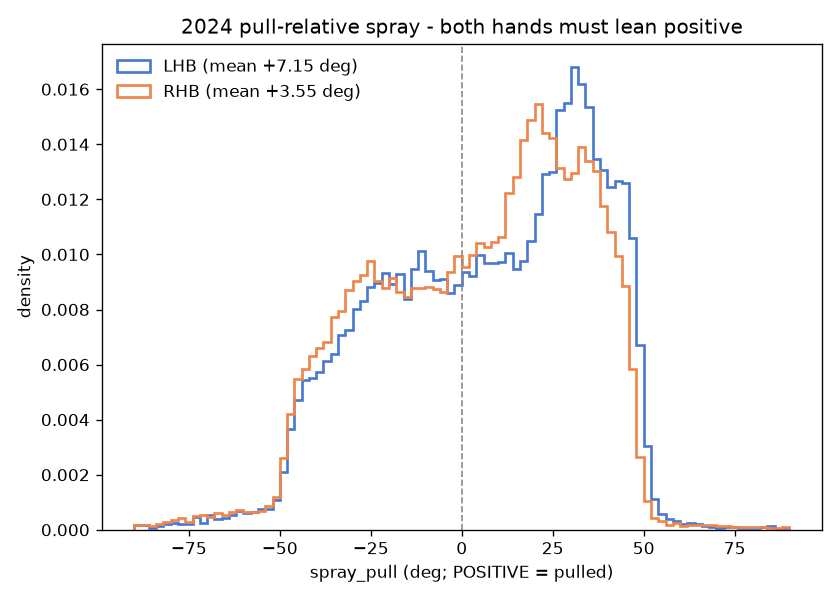

*Mean spray_pull by batter, split by handedness — positive is pulled. Both hands centre well right of zero, mirrored as intended.*

In [12]:
show_fig("stage2_rebuild/figures/spray_by_hand.png",
         caption="Mean spray_pull by batter, split by handedness — positive is pulled. Both hands centre well right of zero, mirrored as intended.")

## 4. Measuring the ruler before reading it — and a false negative

The inputs are sound. Before reading any spray result off them, one more question, and it makes or breaks everything that follows: **how reproducible is a BART fit?** pymc-bart 0.12 draws its trees stochastically and — this surprised me — the fit is *not* reproducible across processes even at a fixed seed. "The model got better" only means something relative to how much the *same model* moves when you simply run it again.

Three identical Stage-A smoke fits (same seed, same data, same code) spread **556 nats** of held-out log-likelihood. At full scale I ran a Stage-C **replicate of the v0 anchor itself** — same three features, same everything — and it landed 267 nats *above* the frozen anchor. That gap is the noise floor: any spray gain smaller than it is indistinguishable from rerunning v0.

*(The 556-nat Stage-A triple is the one figure in this notebook with no committed JSON; it is quoted from `results/RESULTS.md` §"Sampler reproducibility". The Stage-C triple below **is** committed, inside the capacity experiment's verdict file.)*

In [13]:
ref = cap["stage3_m50_reference"]   # committed: results/capacity_C_m200/capacity_metrics.json
STAGE_A_SPREAD = 556.0              # nats; prose-only, see results/RESULTS.md "Sampler reproducibility"
display(pl.DataFrame([
    {"run (m_trees = 50)": "v0 anchor (frozen)",    "features": 3, "holdout ELPD": round(ref["v0_anchor"], 1),   "delta vs anchor": "—"},
    {"run (m_trees = 50)": "v0 replicate (same 3)", "features": 3, "holdout ELPD": round(ref["v0_replicate"], 1), "delta vs anchor": f"{ref['v0_replicate'] - ref['v0_anchor']:+.1f}"},
    {"run (m_trees = 50)": "spray (5 features)",    "features": 5, "holdout ELPD": round(ref["spray"], 1),        "delta vs anchor": f"{ref['spray'] - ref['v0_anchor']:+.1f}"},
]))
Markdown(f"**Noise floor at m=50: {ref['noise_floor']:+.1f} nats** — two runs of the *same* v0 model. "
         f"Spray's apparent **{ref['spray'] - ref['v0_anchor']:+.1f}** sits *inside* it, and against the same-session "
         f"replicate spray is **{ref['spray'] - ref['v0_replicate']:+.1f}** — if anything slightly worse. "
         f"The Stage-A triple spans **{STAGE_A_SPREAD:.0f}** nats for scale.")

run (m_trees = 50),features,holdout ELPD,delta vs anchor
"""v0 anchor (frozen)""",3,-80107.5,"""—"""
"""v0 replicate (same 3)""",3,-79840.4,"""+267.1"""
"""spray (5 features)""",5,-79876.3,"""+231.2"""


**Noise floor at m=50: +267.1 nats** — two runs of the *same* v0 model. Spray's apparent **+231.2** sits *inside* it, and against the same-session replicate spray is **-35.9** — if anything slightly worse. The Stage-A triple spans **556** nats for scale.

So the pre-registered gate failed: a gain smaller than the run-to-run wobble is not a gain. Calibration failed too — weighted ECE **0.0531** for the 5-feature fit against **0.0422** for v0 — and the model reproduced Savant *less* faithfully, event r dropping to 0.873 from 0.911. Without the replicate this would have read as a real-but-sub-threshold improvement. It wasn't an improvement at all.

Here's the twist, and it's what stopped me writing spray off. The model plainly **did learn spray**: in its own variable-importance ranking `spray_pull` came in **third of five**, ahead of both handedness and sprint speed, and the home-run partial-dependence surface climbed from about **0.20** on the oppo side to **0.37** at +40° of pull. The signal was there, correctly signed, and used. It just didn't buy held-out likelihood.

In [14]:
labels50 = sp50["variable_importance"]["feature_labels"]
pl.DataFrame([
    {"m=50 spray fit": "holdout ELPD",              "value": f"{sp50['elpd']['elpd_lppd']:,.1f}",  "v0 anchor": f"{v0['elpd']['elpd_lppd']:,.1f}"},
    {"m=50 spray fit": "weighted ECE",              "value": f"{sp50['calibration']['ece_weighted']:.4f}", "v0 anchor": f"{v0['calibration']['ece_weighted']:.4f}"},
    {"m=50 spray fit": "event r vs Savant",         "value": f"{sp50['replication']['event_r_holdout']:.3f}", "v0 anchor": f"{v0['replication']['event_r_holdout']:.3f}"},
    {"m=50 spray fit": "spray_pull importance rank","value": f"#{sp50['variable_importance']['raw']['indices'].index(labels50.index('spray_pull')) + 1} of {len(labels50)}", "v0 anchor": "n/a"},
    {"m=50 spray fit": "peak P(HR) on the spray PDP","value": f"{sp50['pdp_hr_band']['max_p_hr']:.2f}", "v0 anchor": "n/a"},
])

m=50 spray fit,value,v0 anchor
"""holdout ELPD""","""-79,876.3""","""-80,107.5"""
"""weighted ECE""","""0.0531""","""0.0422"""
"""event r vs Savant""","""0.873""","""0.911"""
"""spray_pull importance rank""","""#3 of 5""","""n/a"""
"""peak P(HR) on the spray PDP""","""0.37""","""n/a"""


Which points at a specific culprit: **capacity dilution, not missing information.** The tree budget was fixed at 50 for both fits, so the same 50 trees now had to cover five features instead of three — every split spent resolving spray is a split no longer spent resolving exit velocity × launch angle. That is a *testable* hypothesis, not a hand-wave. Raise the tree budget, re-fit **both** variants under the new setting, and compare them to each other rather than to a frozen 3-feature anchor.

## 5. The capacity experiment — spray wins, decisively

`scripts/capacity_experiment.py`, run 2026-07-23 at `m_trees = 200`: three fits, ~4.7 hours of compute, all over the same 122,006-event holdout.

1. **v0 at the new capacity** — the fresh anchor.
2. **v0 again** — the replicate, whose gap to (1) *measures* the noise floor at this capacity rather than assuming the m=50 number carries over.
3. **spray at the new capacity** — the treatment.

That second fit is the whole reason the experiment is trustworthy: the ruler gets re-calibrated at the same setting the reading is taken at.

In [15]:
e = cap["elpd"]
display(pl.DataFrame([
    {"run (m_trees = 200)": "v0 (a) — fresh anchor", "features": 3, "holdout ELPD": round(e["v0_a"], 1), "weighted ECE": round(cap["ece"]["v0_a"], 4)},
    {"run (m_trees = 200)": "v0 (b) — replicate",    "features": 3, "holdout ELPD": round(e["v0_b"], 1), "weighted ECE": round(cap["ece"]["v0_b"], 4)},
    {"run (m_trees = 200)": "spray",                 "features": 5, "holdout ELPD": round(e["spray"], 1), "weighted ECE": round(cap["ece"]["spray"], 4)},
]))
pa, pb_ = cap["paired_vs_v0_a"], cap["paired_vs_v0_b"]
pl.DataFrame([
    {"comparison": "null noise floor |v0_a − v0_b|",   "nats": f"{cap['noise_floor_nats']:.1f}", "95% CI": "—", "note": "the ruler, re-measured at m=200"},
    {"comparison": "spray − mean(v0), unpaired",       "nats": f"{cap['spray_minus_v0_mean']:+,.0f}", "95% CI": "—", "note": f"{cap['spray_minus_v0_mean'] / cap['noise_floor_nats']:.0f}x the floor"},
    {"comparison": "spray − v0(a), paired per event",  "nats": f"{pa['total_delta_nats']:+,.0f}", "95% CI": f"[{pa['ci95_nats'][0]:+,.0f}, {pa['ci95_nats'][1]:+,.0f}]", "note": f"better on {pa['frac_events_better']:.1%} of events"},
    {"comparison": "spray − v0(b), paired per event",  "nats": f"{pb_['total_delta_nats']:+,.0f}", "95% CI": f"[{pb_['ci95_nats'][0]:+,.0f}, {pb_['ci95_nats'][1]:+,.0f}]", "note": f"better on {pb_['frac_events_better']:.1%} of events"},
])

run (m_trees = 200),features,holdout ELPD,weighted ECE
"""v0 (a) — fresh anchor""",3,-75117.4,0.0277
"""v0 (b) — replicate""",3,-75154.1,0.0263
"""spray""",5,-72118.4,0.0369


comparison,nats,95% CI,note
"""null noise floor |v0_a − v0_b|""","""36.7""","""—""","""the ruler, re-measured at m=20…"
"""spray − mean(v0), unpaired""","""+3,017""","""—""","""82x the floor"""
"""spray − v0(a), paired per even…","""+2,999""","""[+2,877, +3,120]""","""better on 57.6% of events"""
"""spray − v0(b), paired per even…","""+3,036""","""[+2,913, +3,156]""","""better on 57.6% of events"""


**+3,017 nats against a 37-nat floor — 82× the noise, with paired CIs nowhere near zero.** The m=50 "negative" was a capacity artifact, and it is now confirmed as one rather than merely suspected.

The scale of the correction is worth pausing on. Going from 50 trees to 200 lifted **both** models enormously — v0 by **+4,990** nats, spray by **+7,758** — and collapsed the noise floor from 267 to 37. The m=50 fits were simply under-capacity for 122k events; *both* were, which is why the difference between them was uninformative. The paired test is also what makes the interval so tight: both models are driven mostly by the same exit-velocity × launch-angle signal, so their per-event errors are strongly correlated and the paired spread is far smaller than the ±244 on either total. Holdout-order digests were asserted identical across all three fits, so the pairing compares matched events rather than silently misaligned ones.

In [16]:
ref = cap["stage3_m50_reference"]
pl.DataFrame([
    {"quantity": "v0 holdout ELPD",    "at m=50": f"{ref['v0_anchor']:,.0f}", "at m=200": f"{e['v0_a']:,.0f}",
     "change": f"{e['v0_a'] - ref['v0_anchor']:+,.0f} nats"},
    {"quantity": "spray holdout ELPD", "at m=50": f"{ref['spray']:,.0f}",     "at m=200": f"{e['spray']:,.0f}",
     "change": f"{e['spray'] - ref['spray']:+,.0f} nats"},
    {"quantity": "run-to-run noise floor", "at m=50": f"{ref['noise_floor']:.1f}", "at m=200": f"{cap['noise_floor_nats']:.1f}",
     "change": f"the ruler got {ref['noise_floor'] / cap['noise_floor_nats']:.0f}x finer"},
])

quantity,at m=50,at m=200,change
"""v0 holdout ELPD""","""-80,107""","""-75,117""","""+4,990 nats"""
"""spray holdout ELPD""","""-79,876""","""-72,118""","""+7,758 nats"""
"""run-to-run noise floor""","""267.1""","""36.7""","""the ruler got 7x finer"""


And here is what the extra capacity let the model see. **What to look for:** the home-run band at launch angles around 25–35° leaning hard to the pulled side — P(HR) peaking near **0.69** at roughly +38° of pull, against a low ceiling on the opposite-field side. That gradient is real baseball (pulled contact in the air is the home-run zone) and the model found it unaided.

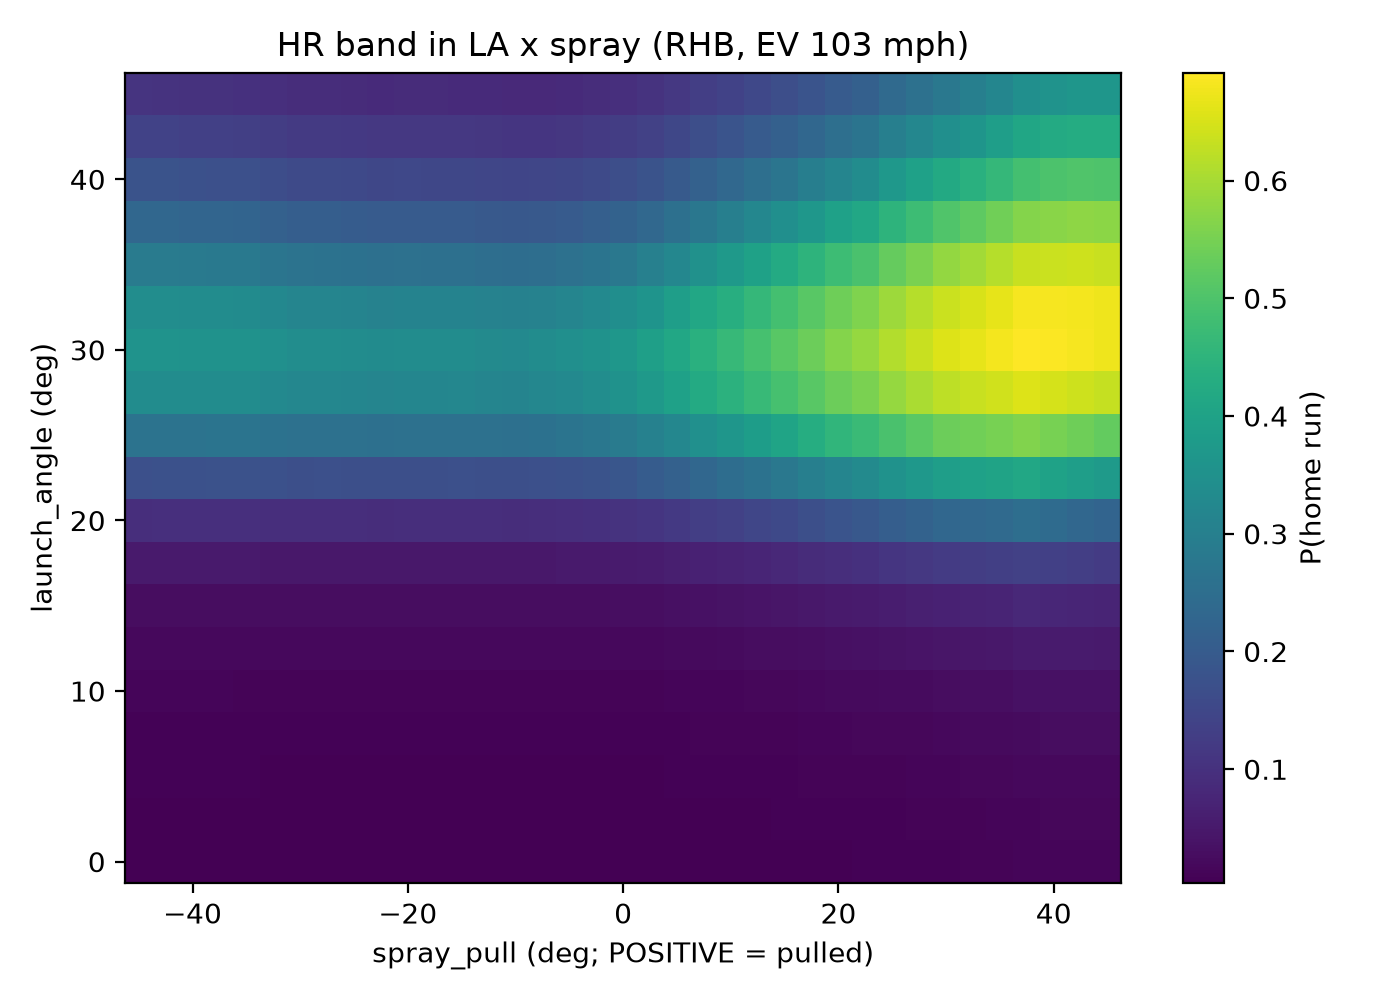

*P(home run) across launch angle and spray at m=200 — peak 0.69 at LA 30 deg, spray +37.5 deg (pull).*

In [17]:
show_fig("stage_C_spray_m200/figures/pdp_la_spray_hr.png",
         caption=f"P(home run) across launch angle and spray at m=200 — peak {sp200['pdp_hr_band']['max_p_hr']:.2f} at "
                 f"LA {sp200['pdp_hr_band']['argmax_la']:.0f} deg, spray +{sp200['pdp_hr_band']['argmax_spray']:.1f} deg (pull).")

**What to look for below:** `spray_pull` entering third, right after the two features that carry the surface — the same rank it held at m=50, except now the capacity exists to pay for it.

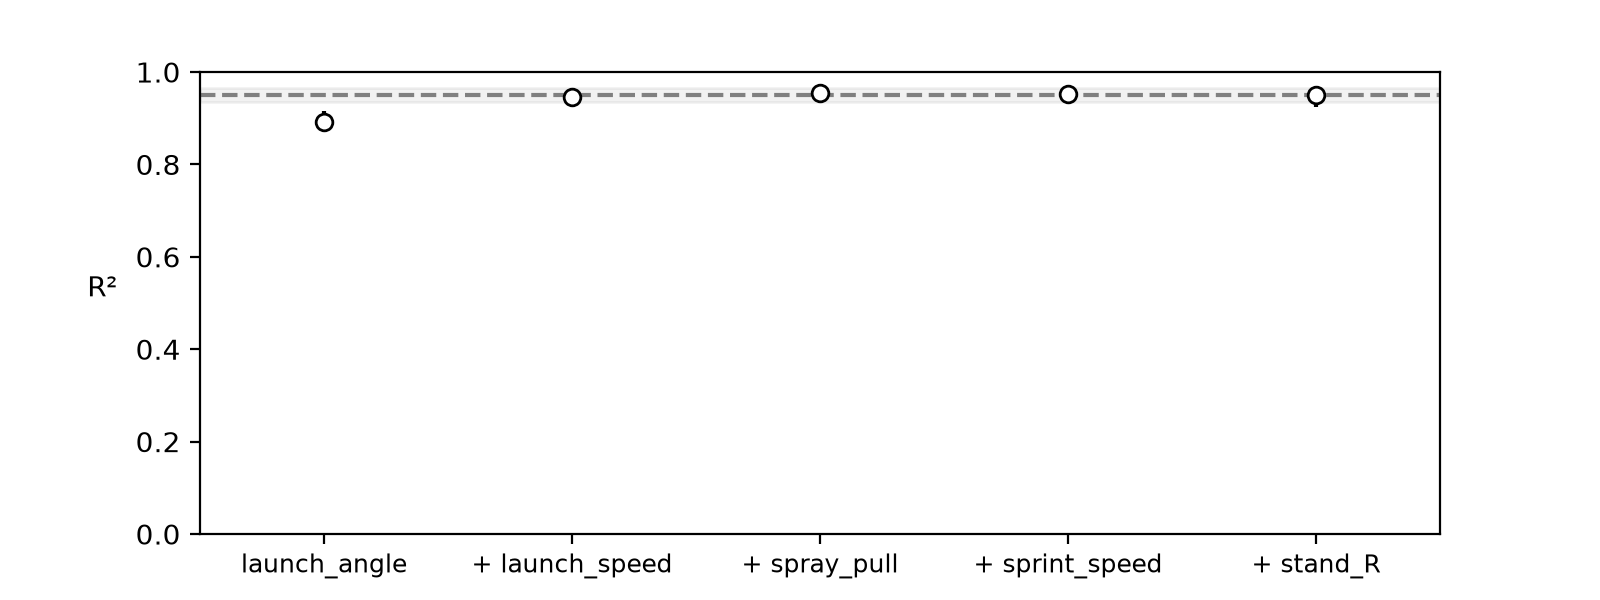

*Cumulative R2 as features join, most important first (bare feature indices on the x axis) — launch angle, launch speed, then spray_pull.*

In [18]:
show_fig("stage_C_spray_m200/figures/variable_importance.png",
         caption="Cumulative R2 as features join, most important first (bare feature indices on the x axis) — launch angle, launch speed, then spray_pull.")

In [19]:
labels200 = sp200["variable_importance"]["feature_labels"]
order200 = sp200["variable_importance"]["raw"]["indices"]
pl.DataFrame([{"rank": i + 1, "feature": labels200[idx]} for i, idx in enumerate(order200)])

rank,feature
1,"""launch_angle"""
2,"""launch_speed"""
3,"""spray_pull"""
4,"""sprint_speed"""
5,"""stand_R"""


## 6. What the win does *not* buy

Two things travel with this result, and leaving either out would misrepresent it.

**Calibration regressed.** The spray surface buys likelihood and sharpness at some cost to honest probabilities — weighted ECE **0.0369** against the matched v0's **0.0277** / **0.0263**. That is the same tension the m=50 fit showed, and it did not go away with capacity; it is just no longer accompanied by a likelihood loss. (The reliability strip for this fit is committed at `results/stage_C_spray_m200/figures/calibration_reliability.png`; I'm letting the number carry it here rather than spend a 5-panel figure on one number.) Worth noting alongside: at m=200 plain v0 reproduces Savant *better* than it did at m=50 — player r **0.982** vs 0.956 — so the capacity lift is not a spray-specific effect.

**The prediction wall from §2 is still standing.** The surface describes a batted ball better; that is not the same claim as predicting a hitter's next season better. The one downstream test I ran — does *using* each ball's spray when rolling up to a player-season help predict next season? — says no, and says it cleanly.

In [20]:
def rmse3(block):   # calibrated RMSE, x10^-3
    return round(ra["pooled_pa30"][block]["rmse_calibrated"] * 1000, 2)
pbr = ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]
display(pl.DataFrame([
    {"season rollup (PA>=30)": "conditioned on spray",    "next-season calibrated RMSE x10^-3": rmse3("xwoba_conditioned")},
    {"season rollup (PA>=30)": "marginalized over spray", "next-season calibrated RMSE x10^-3": rmse3("xwoba_marginalized")},
    {"season rollup (PA>=30)": "v0 (no spray)",           "next-season calibrated RMSE x10^-3": rmse3("xwoba_v0")},
    {"season rollup (PA>=30)": "Savant",                  "next-season calibrated RMSE x10^-3": rmse3("xwoba_savant")},
]))
Markdown(f"**Conditioned − marginalized:** +{ra['verdict']['delta_rmse_pa30_cond_minus_marg']:.6f} calibrated RMSE, "
         f"95% CI [+{pbr['ci95'][0]:.6f}, +{pbr['ci95'][1]:.6f}], conditioned better in "
         f"{pbr['frac_better']:.0%} of {ra['paired_bootstrap_pa30']['n_reps']:,} resamples — reliably the wrong "
         f"direction, but far under the 0.001 bar that would make it matter. **The column that matters is the "
         f"third: both spray rollups lose to plain v0.**")

season rollup (PA>=30),next-season calibrated RMSE x10^-3
"""conditioned on spray""",36.59
"""marginalized over spray""",36.27
"""v0 (no spray)""",35.82
"""Savant""",35.56


**Conditioned − marginalized:** +0.000317 calibrated RMSE, 95% CI [+0.000189, +0.000458], conditioned better in 0% of 5,000 resamples — reliably the wrong direction, but far under the 0.001 bar that would make it matter. **The column that matters is the third: both spray rollups lose to plain v0.**

**What to look for:** the two spray rollups tracking *above* v0 (worse) across the whole PA range — adding spray to the season rollup never helps.

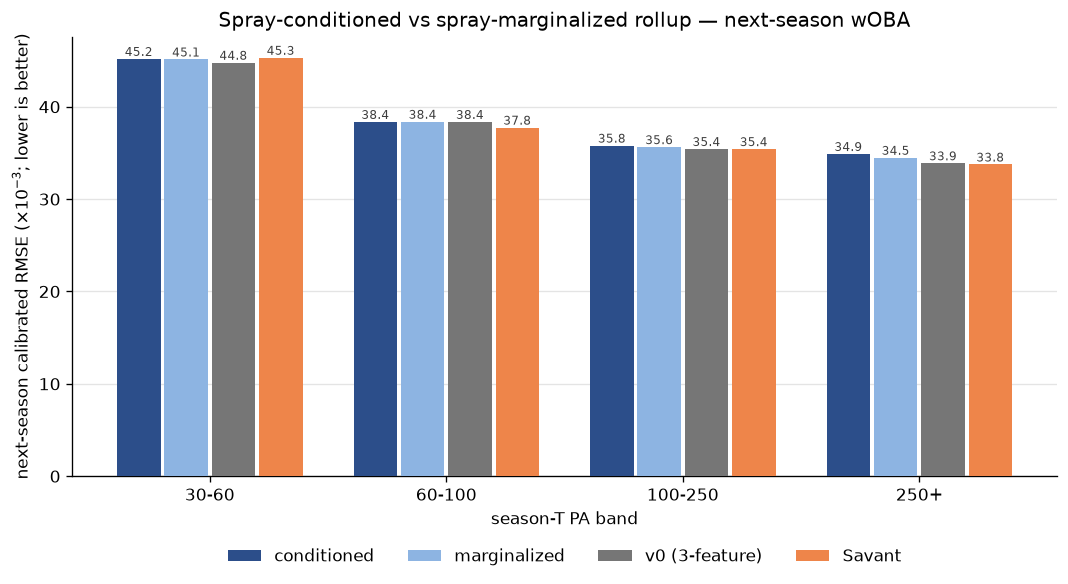

*Next-season xwOBA RMSE by PA band — conditioned and marginalized spray rollups vs v0 and Savant. v0 sits at or below both spray variants everywhere.*

In [21]:
show_fig("rollup_ab/figures/next_season_rmse_by_band.png",
         caption="Next-season xwOBA RMSE by PA band — conditioned and marginalized spray rollups vs v0 and Savant. v0 sits at or below both spray variants everywhere.")

One honest caveat on that table: the rollup A/B was built from the **m=50** spray draws, and it has not been re-run on the m=200 fit. So strictly it shows that the *diluted* spray surface didn't help prediction. The forecasting question gets settled directly and independently in Part 3, on a pre-check that never touches the surface at all — and it comes back the same way.

## Takeaway

Spray resolves as **description-yes, prediction-no**.

The surface half is now settled and it's a real win: given adequate tree capacity, the information Savant throws away — where the ball was hit, and which hand hit it — makes the model substantially better at valuing a batted ball, by 82 noise floors. It took measuring the sampler's own run-to-run wobble twice to know that, and the first measurement produced a confident negative that was wrong.

But §2's wall is untouched. Better description has not become better prediction of what a hitter does next, and calibration got worse in the trade. If raw accuracy against next season is capped by the information available, then the value has to come from somewhere else: not a better point estimate, but an honest account of **how sure we are** about the one we have, and of the **true talent** underneath it. That's Part 2.

Full write-ups: `results/RESULTS.md` (§"Spray at matched capacity — the m=200 result"), `results/stage2_rebuild/NOTES.md`, `results/rollup_ab/NOTES.md`.

In [22]:
# guard: every number quoted in the prose above, checked against the committed artifacts under
# results/ — fails loudly instead of letting the text silently drift out of date.
# (The only prose-only number is the 556-nat Stage-A triple, quoted from results/RESULTS.md
#  section "Sampler reproducibility"; there is no metrics.json for those three smoke fits.)

# -- 1. v0 reproduces Savant
assert round(v0["replication"]["player_r_holdout"], 3) == 0.956
assert round(v0["calibration"]["ece_weighted"], 3) == 0.042
assert round(v0["elpd"]["elpd_lppd"]) == -80107 and round(v0["elpd"]["elpd_se"]) == 244
assert round(v0["elpd"]["n_events"] / 1000) == 122
assert v0["variable_importance"]["raw"]["indices"][0] == 1                      # launch_angle enters first
assert [round(x, 3) for x in v0["variable_importance"]["raw"]["r2_mean"]] == [0.853, 0.861, 0.862]
assert round(v0["localization"]["weak_topped_sprint_corr"], 2) == 0.03
assert round(v0["localization"]["solid_barrel_sprint_corr"], 3) == 0.002

# -- 2. the parity wall
assert bm["n_pairs"] == 1058
assert round(bm["pooled"]["model"]["r"], 3) == 0.481 and round(bm["pooled"]["savant"]["r"], 3) == 0.487
assert round(bm["pooled"]["naive"]["r"], 2) == 0.39
assert bm["model_vs_savant_bootstrap"]["ci95"][0] < 0 < bm["model_vs_savant_bootstrap"]["ci95"][1]
_per = bm["per_pair"]
assert (_per["2022->2023"]["savant"]["r"] > _per["2022->2023"]["model"]["r"]
        and _per["2023->2024"]["model"]["r"] > _per["2023->2024"]["savant"]["r"]
        and _per["2024->2025"]["model"]["r"] > _per["2024->2025"]["savant"]["r"])

# -- 3. the rebuilt inputs and their sign
assert all(g["pass"] for g in rb["gates"]) and [g["name"][:2] for g in rb["gates"]] == ["R1", "R2", "R3", "R4", "R5", "R6"]
assert all(rb["before"][y]["digest"] == rb["after"][y]["digest"] for y in ("2022", "2023", "2024", "2025"))
assert all(g["pass"] for g in qc["gates"]) and len(qc["gates"]) == 6
_L = [qc["per_season"][y]["mean_pull"]["L"] for y in ("2022", "2023", "2024", "2025")]
_R = [qc["per_season"][y]["mean_pull"]["R"] for y in ("2022", "2023", "2024", "2025")]
assert (round(min(_L), 2), round(max(_L), 2)) == (6.84, 7.50)
assert (round(min(_R), 2), round(max(_R), 2)) == (3.23, 3.62)
assert round(qc["named_2024"]["Kyle Schwarber"]["mean_pull"], 2) == 13.90
assert round(qc["named_2024"]["Ryan Mountcastle"]["mean_pull"], 2) == -5.16
assert qc["n_switch_2024"] == 65
_sw = {s["stand"]: s for s in qc["switch_by_stand"]}
assert round(_sw["L"]["mean_pull"], 2) == 8.68 and round(_sw["R"]["mean_pull"], 2) == 5.60

# -- 4. the m=50 false negative (the reference block cross-checks against the stage metrics)
_ref = cap["stage3_m50_reference"]
assert _ref["m_trees"] == 50 and round(_ref["noise_floor"], 1) == 267.1
assert round(_ref["v0_anchor"], 1) == round(v0["elpd"]["elpd_lppd"], 1) == -80107.5
assert round(_ref["spray"], 1) == round(sp50["elpd"]["elpd_lppd"], 1) == -79876.3
assert round(_ref["spray"] - _ref["v0_anchor"], 1) == 231.2                     # inside the 267 floor
assert round(_ref["spray"] - _ref["v0_replicate"], 1) == -35.9                  # worse than the replicate
assert round(sp50["calibration"]["ece_weighted"], 4) == 0.0531
assert round(sp50["replication"]["event_r_holdout"], 3) == 0.873
assert sp50["variable_importance"]["raw"]["indices"] == [1, 0, 2, 3, 4]         # spray_pull ranks #3 of 5
assert sp50["variable_importance"]["feature_labels"][2] == "spray_pull"
assert round(sp50["pdp_hr_band"]["max_p_hr"], 2) == 0.37

# -- 5. the m=200 capacity experiment
assert cap["m_trees"] == 200 and cap["n_events"] == 122006
assert cap["paired_valid"] and len(set(cap["holdout_order_digests"].values())) == 1
assert round(cap["noise_floor_nats"], 1) == 36.7
assert round(cap["spray_minus_v0_mean"]) == 3017
assert round(cap["spray_minus_v0_mean"] / cap["noise_floor_nats"]) == 82
assert cap["unpaired_beats"] and cap["unpaired_verdict"].startswith("BEATS")
for _p in (cap["paired_vs_v0_a"], cap["paired_vs_v0_b"]):
    assert _p["significant"] and _p["direction"] == "better" and _p["ci95_nats"][0] > 0
assert round(cap["paired_vs_v0_a"]["total_delta_nats"]) == 2999
assert round(cap["paired_vs_v0_a"]["frac_events_better"], 3) == 0.576
assert round(cap["elpd"]["v0_a"] - _ref["v0_anchor"]) == 4990                   # capacity lifts v0 too
assert round(cap["elpd"]["spray"] - _ref["spray"]) == 7758
assert round(sp200["pdp_hr_band"]["max_p_hr"], 2) == 0.69
assert round(sp200["pdp_hr_band"]["argmax_la"]) == 30 and round(sp200["pdp_hr_band"]["argmax_spray"], 1) == 37.5
assert sp200["variable_importance"]["feature_labels"][2] == "spray_pull"
assert sp200["variable_importance"]["raw"]["indices"][2] == 2                   # spray_pull enters third
assert sp200["stage_settings"]["m_trees"] == v200a["stage_settings"]["m_trees"] == 200

# -- 6. the caveats
assert round(cap["ece"]["spray"], 4) == 0.0369
assert round(cap["ece"]["v0_a"], 4) == 0.0277 and round(cap["ece"]["v0_b"], 4) == 0.0263
assert round(v200a["replication"]["player_r_holdout"], 3) == 0.982
assert round(ra["pooled_pa30"]["xwoba_conditioned"]["rmse_calibrated"] * 1000, 2) == 36.59
assert round(ra["pooled_pa30"]["xwoba_marginalized"]["rmse_calibrated"] * 1000, 2) == 36.27
assert round(ra["pooled_pa30"]["xwoba_v0"]["rmse_calibrated"] * 1000, 2) == 35.82
assert round(ra["pooled_pa30"]["xwoba_savant"]["rmse_calibrated"] * 1000, 2) == 35.56
assert round(ra["verdict"]["delta_rmse_pa30_cond_minus_marg"], 6) == 0.000317
_ci = ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]["ci95"]
assert round(_ci[0], 6) == 0.000189 and round(_ci[1], 6) == 0.000458
assert ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]["frac_better"] == 0.0

print("prose numbers still match the artifacts")

prose numbers still match the artifacts
